# Simulating RDE Voltammetry for an Oxidation with Butler–Volmer Kinetics & Koutecký–Levich Analysis using `solve_ivp`

In hydrodynamic electrochemistry, a **Rotating Disk Electrode (RDE)** establishes a steady laminar convection pattern that transports fresh reactant from bulk solution directly toward the electrode surface.

Directly simulating this convective-diffusion process generally requires solving coupled 2D or axisymmetric Navier–Stokes fluid flow equations alongside mass transport:
$$\frac{\partial c}{\partial t} + \mathbf{v} \cdot \nabla c = D \nabla^2 c$$
In 1942, **V. G. Levich** proved that steady laminar flow establishes a hydrodynamic boundary layer that translates into a uniform, stagnant diffusion boundary layer of thickness $\delta$:
$$\delta = 1.61 \, D^{1/3} \, \nu^{1/6} \, \omega^{-1/2}$$
where:
- $D$ is the diffusion coefficient ($\text{cm}^2/\text{s}$, with $D_{\text{Red}} = D_{\text{Ox}} = D$)
- $\nu$ is the kinematic viscosity of the solution ($\approx 0.01\text{ cm}^2/\text{s}$ for water at $25^\circ\text{C}$)
- $\omega = 2\pi (\text{rpm}/60)$ is the angular rotation velocity ($\text{rad/s}$)

### Hydrodynamics without Fluid Flow: The Nernst Diffusion Layer Model
By transforming the rotation speed $\omega$ into this fixed stagnant layer thickness $\delta$, we avoid simulating fluid mechanics entirely. The physical problem reduces to 1D diffusion across a finite domain $x \in [0, \delta]$:
- At the outer boundary ($x = \delta$): strong convective replenishment maintains bulk composition ($c_{\text{Red}} = c^*$, $c_{\text{Ox}} = 0$).
- At the electrode surface ($x = 0$): charge transfer is governed by **Butler–Volmer kinetics**.

### IUPAC Convention & Oxidation Reaction
Under standard **IUPAC conventions**:
- **Reaction**: Single-electron oxidation $\text{Red} \underset{k_{\text{red}}}{\overset{k_{\text{ox}}}{\rightleftharpoons}} \text{Ox} + e^-$.
- **Potential sweep**: Starts at reducing/non-reacting potentials ($E_{\text{start}} = -0.30\text{ V}$ vs. $E^{0'}$), sweeps anodically (in the positive direction) to $E_{\text{vertex}} = +0.30\text{ V}$, and reverses back.
- **Current sign**: **Anodic oxidation current is positive** ($I > 0$), while cathodic reduction current is negative ($I < 0$).

### What You Will Learn
1. **Formulate 1D diffusion PDEs with Butler–Volmer oxidation kinetics** across the finite Nernst boundary layer $[0, \delta]$ under IUPAC conventions.
2. **Discretize the interfacial flux coupling** using a second-order ghost-node scheme for `scipy.integrate.solve_ivp`.
3. **Simulate spatio-temporal concentration profiles** $c_{\text{Red}}(x, t)$ and $c_{\text{Ox}}(x, t)$ to visualize the formation of the steady-state linear gradient.
4. **Vary rotation speed at fixed scan rate** and compare the diffusion-limited oxidation current against the analytical **Levich equation**.
5. **Normalize voltammograms** ($I / I_L$ vs. $E$) to isolate and visualize kinetic overpotential shifts.
6. **Perform Koutecký–Levich (K-L) analysis** to quantitatively extract the standard heterogeneous rate constant $k_0$ and transfer coefficient $\alpha$.

## 1. Physical Model & Governing Equations

### Governing Diffusion Equations
For a single-electron oxidation ($\text{Red} \rightleftharpoons \text{Ox} + e^-$) with equal diffusion coefficients ($D_{\text{Red}} = D_{\text{Ox}} = D$), 1D mass transport across $x \in [0, \delta]$ obeys Fick's second law:
$$\frac{\partial c_{\text{Red}}}{\partial t} = D \frac{\partial^2 c_{\text{Red}}}{\partial x^2}, \qquad \frac{\partial c_{\text{Ox}}}{\partial t} = D \frac{\partial^2 c_{\text{Ox}}}{\partial x^2}$$
with initial conditions $c_{\text{Red}}(x, 0) = c^*$ and $c_{\text{Ox}}(x, 0) = 0$.

### Boundary Conditions
1. **Bulk Solution ($x = \delta$)**: Convective flow rapidly flushes the outer boundary:
   $$c_{\text{Red}}(\delta, t) = c^*, \qquad c_{\text{Ox}}(\delta, t) = 0$$
2. **Electrode Surface ($x = 0$)**: Interfacial Butler–Volmer oxidation flux:
   $$J(t) = D \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} = - D \left.\frac{\partial c_{\text{Ox}}}{\partial x}\right|_{x=0} = k_{\text{ox}}(t) c_{\text{Red}}(0, t) - k_{\text{red}}(t) c_{\text{Ox}}(0, t)$$
   where the potential-dependent heterogeneous rate constants are:
   $$k_{\text{ox}}(t) = k_0 \exp\left[ (1 - \alpha) \frac{F}{RT} (E(t) - E^{0'}) \right], \qquad k_{\text{red}}(t) = k_0 \exp\left[ -\alpha \frac{F}{RT} (E(t) - E^{0'}) \right]$$
   Under the IUPAC convention, the Faradaic oxidation current is positive:
   $$I(t) = n F A J(t) = n F A D \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} > 0$$

### Analytical Benchmarks
- **Levich Equation (Mass-Transport Limited Current)**:
  When driven to extreme positive overpotentials, $c_{\text{Red}}(0, t) \to 0$, producing a steady linear gradient $\partial c_{\text{Red}}/\partial x = c^* / \delta$:
  $$I_L = \frac{n F A D c^*}{\delta} = 0.620 \, n F A D^{2/3} \nu^{-1/6} c^* \omega^{1/2}$$
- **Koutecký–Levich Equation (Mixed Kinetic-Mass Transport Control)**:
  At intermediate anodic potentials where kinetics and mass transfer both limit the current:
  $$\frac{1}{I(E)} = \frac{1}{I_k(E)} + \frac{1}{I_L(\omega)} = \frac{1}{n F A c^* k_{\text{ox}}(E)} + \frac{1}{B \omega^{1/2}}$$
  where $B = 0.620 \, n F A D^{2/3} \nu^{-1/6} c^*$ is the Levich constant.
- **Tafel Kinetic Extraction for Oxidation**:
  The potential-dependent kinetic current $I_k(E)$ satisfies:
  $$\ln I_k(E) = \ln(n F A c^* k_0) + (1 - \alpha) \frac{F}{RT} (E - E^{0'})$$
  A linear regression of $\ln I_k(E)$ vs. $(E - E^{0'})$ yields:
  $$\text{slope} = (1 - \alpha) \frac{F}{RT} \implies \alpha = 1 - \text{slope} \cdot \frac{RT}{F}$$
  $$k_0 = \frac{\exp(\text{intercept})}{n F A c^*}$$

In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("IPYTHONDIR", "/tmp/ipython")

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats import linregress

# Physical constants
F = 96485.332  # Faraday constant (C/mol)
R = 8.3145  # Gas constant (J/(mol*K))
T = 298.15  # Temperature (K)
f = F / (R * T)  # Normalized potential factor (~38.92 V^-1)

# Electrochemical & Hydrodynamic parameters
n = 1  # Number of electrons transferred
A = 0.07  # Electrode geometric area (cm²)
c_bulk = 1.0e-6  # Bulk concentration of reactant Red (mol/cm³, 1.0 mM)
D = 1.0e-5  # Diffusion coefficient D_Red = D_Ox (cm²/s)
nu = 0.01  # Kinematic viscosity of water at 25 °C (cm²/s)
E0 = 0.0  # Formal potential (V)

# Ground-truth Butler-Volmer kinetic parameters
k0_true = 2.0e-3  # Standard heterogeneous rate constant (cm/s, quasi-reversible)
alpha_true = 0.50  # Charge transfer coefficient

# Potential sweep parameters (IUPAC: sweep anodically from -0.3 V to +0.3 V)
E_start = -0.30  # Initial reducing potential (V)
E_vertex = 0.30  # Vertex oxidizing potential (V)
v_scan = 0.01  # Scan rate: 10 mV/s (quasi-steady state)

print(
    f"Simulating RDE oxidation: A = {A} cm², D = {D:.1e} cm²/s, k0 = {k0_true:.1e} cm/s, alpha = {alpha_true}"
)

Simulating RDE oxidation: A = 0.07 cm², D = 1.0e-05 cm²/s, k0 = 2.0e-03 cm/s, alpha = 0.5


## 2. Spatial Discretization (Method of Lines) & Ghost-Node Formulation

To solve the system using `solve_ivp`, we discretize the spatial domain $x \in [0, \delta]$ with $N$ uniform grid points:
$$\Delta x = \frac{\delta}{N - 1}, \qquad x_j = j \Delta x \quad (j = 0, \dots, N-1)$$

### Interior Nodes ($j = 1, \dots, N-2$)
Fick's second law is approximated by second-order central differences:
$$\frac{d c_{\text{Red}, j}}{dt} = \frac{D}{\Delta x^2} (c_{\text{Red}, j+1} - 2 c_{\text{Red}, j} + c_{\text{Red}, j-1})$$
$$\frac{d c_{\text{Ox}, j}}{dt} = \frac{D}{\Delta x^2} (c_{\text{Ox}, j+1} - 2 c_{\text{Ox}, j} + c_{\text{Ox}, j-1})$$

### Electrode Surface ($x = 0$, $j = 0$)
Introducing a fictitious ghost node at $x = -\Delta x$, the central difference for the surface flux gives:
$$\left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} \approx \frac{c_{\text{Red}, 1} - c_{\text{Red}, -1}}{2 \Delta x} = \frac{J(t)}{D} \implies c_{\text{Red}, -1} = c_{\text{Red}, 1} - \frac{2 \Delta x}{D} J(t)$$
Substituting $c_{\text{Red}, -1}$ into the central difference diffusion operator at $j = 0$ yields:
$$\frac{d c_{\text{Red}, 0}}{dt} = \frac{2 D}{\Delta x^2} (c_{\text{Red}, 1} - c_{\text{Red}, 0}) - \frac{2}{\Delta x} J(t)$$
Similarly, for species $\text{Ox}$ with surface flux $\left.\frac{\partial c_{\text{Ox}}}{\partial x}\right|_{x=0} = -J(t)/D$:
$$\frac{d c_{\text{Ox}, 0}}{dt} = \frac{2 D}{\Delta x^2} (c_{\text{Ox}, 1} - c_{\text{Ox}, 0}) + \frac{2}{\Delta x} J(t)$$

### Outer Boundary ($x = \delta$, $j = N-1$)
Convective replenishment pins the concentrations to bulk values, so $\frac{d c_{\text{Red}, N-1}}{dt} = 0$ and $\frac{d c_{\text{Ox}, N-1}}{dt} = 0$.

### Surface Current Reconstruction
Following Fick's first law under the IUPAC convention, Faradaic anodic oxidation current is evaluated directly from the second-order surface gradient:
$$I(t) = n F A D \left.\frac{\partial c_{\text{Red}}}{\partial x}\right|_{x=0} \approx n F A D \left( \frac{-3 c_{\text{Red}, 0} + 4 c_{\text{Red}, 1} - c_{\text{Red}, 2}}{2 \Delta x} \right)$$

In [2]:
def calculate_delta(rpm: float) -> float:
    """Calculate Nernst stagnant diffusion layer thickness (cm) from rotation speed."""
    omega = 2.0 * np.pi * (rpm / 60.0)
    return 1.61 * (D ** (1.0 / 3.0)) * (nu ** (1.0 / 6.0)) * (omega**-0.5)


def simulate_rde_bv(
    rpm: float,
    v: float = 0.01,
    k0: float = 2.0e-3,
    alpha: float = 0.50,
    N: int = 61,
    n_eval: int = 501,
) -> dict:
    """Simulate RDE cyclic voltammetry for an oxidation with Butler-Volmer kinetics."""
    delta = calculate_delta(rpm)
    x = np.linspace(0.0, delta, N)
    dx = x[1] - x[0]
    inv_dx2 = 1.0 / (dx**2)

    t_switch = (E_vertex - E_start) / v
    t_end = 2.0 * t_switch

    def rhs(t: float, y: np.ndarray) -> np.ndarray:
        c_R, c_O = y[:N], y[N:]
        # Triangular potential waveform: forward anodic, reverse cathodic
        E = E_start + v * t if t <= t_switch else E_vertex - v * (t - t_switch)
        eta = E - E0
        k_ox = k0 * np.exp((1.0 - alpha) * f * eta)
        k_red = k0 * np.exp(-alpha * f * eta)
        J = k_ox * c_R[0] - k_red * c_O[0]  # Net interfacial oxidation flux

        dy = np.empty_like(y)
        # Interior diffusion (Fick's second law)
        dy[1 : N - 1] = D * (c_R[2:] - 2.0 * c_R[1:-1] + c_R[:-2]) * inv_dx2
        dy[N + 1 : 2 * N - 1] = D * (c_O[2:] - 2.0 * c_O[1:-1] + c_O[:-2]) * inv_dx2

        # Electrode surface x = 0 (2nd-order ghost node)
        dy[0] = 2.0 * D * (c_R[1] - c_R[0]) * inv_dx2 - (2.0 / dx) * J
        dy[N] = 2.0 * D * (c_O[1] - c_O[0]) * inv_dx2 + (2.0 / dx) * J

        # Outer boundary x = delta (convective bulk Dirichlet)
        dy[N - 1] = 0.0
        dy[2 * N - 1] = 0.0
        return dy

    # Initial condition: uniform bulk c_Red, zero c_Ox
    y0 = np.concatenate([np.full(N, c_bulk), np.zeros(N)])
    t_eval = np.linspace(0.0, t_end, n_eval)

    # Solve stiff ODE system using BDF
    sol = solve_ivp(
        rhs,
        (0.0, t_end),
        y0,
        method="BDF",
        t_eval=t_eval,
        rtol=1e-6,
        atol=1e-10,
    )

    # Compute potential and anodic Faradaic current (in uA, positive for oxidation under IUPAC)
    E_vals = np.array(
        [
            E_start + v * t if t <= t_switch else E_vertex - v * (t - t_switch)
            for t in t_eval
        ]
    )
    grad_R = (-3.0 * sol.y[0] + 4.0 * sol.y[1] - sol.y[2]) / (2.0 * dx)
    I_vals = n * F * A * D * grad_R * 1e6  # Current in uA (anodic oxidation positive)

    return {
        "sol": sol,
        "t": t_eval,
        "x": x,
        "E": E_vals,
        "I": I_vals,
        "delta": delta,
        "t_switch": t_switch,
        "rpm": rpm,
        "omega": 2.0 * np.pi * (rpm / 60.0),
    }

## 3. Baseline Simulation & Spatio-Temporal Concentration Profiles

We first simulate a baseline oxidation scan at $\text{rpm} = 900$ ($\omega \approx 94.25\text{ rad/s}$, $\delta \approx 16.6\,\mu\text{m}$) with $v = 10\text{ mV/s}$.

At this slow scan rate ($t_{\text{switch}} = 60\text{ s}$ vs. diffusion relaxation time $\tau_D = \delta^2 / D \approx 0.028\text{ s}$), mass transport operates in quasi-steady-state:
- At $E = -0.3\text{ V}$: No oxidation occurs; $c_{\text{Red}}(x) = c^*$ throughout $[0, \delta]$.
- At $E \approx +0.06\text{ V}$ (half-wave potential $E_{1/2}$): Surface concentration $c_{\text{Red}}(0)$ drops to $\sim 0.5\,c^*$, forming a linear diffusion gradient across $[0, \delta]$.
- At $E = +0.3\text{ V}$ (vertex / limiting plateau): Surface reactant is completely exhausted ($c_{\text{Red}}(0) \to 0$); the gradient reaches its maximum steady-state slope $c^* / \delta$, delivering the Levich limiting oxidation current.
- During reverse cathodic scan: Forward and reverse sweeps overlap with negligible hysteresis, typical of hydrodynamic steady-state voltammetry.

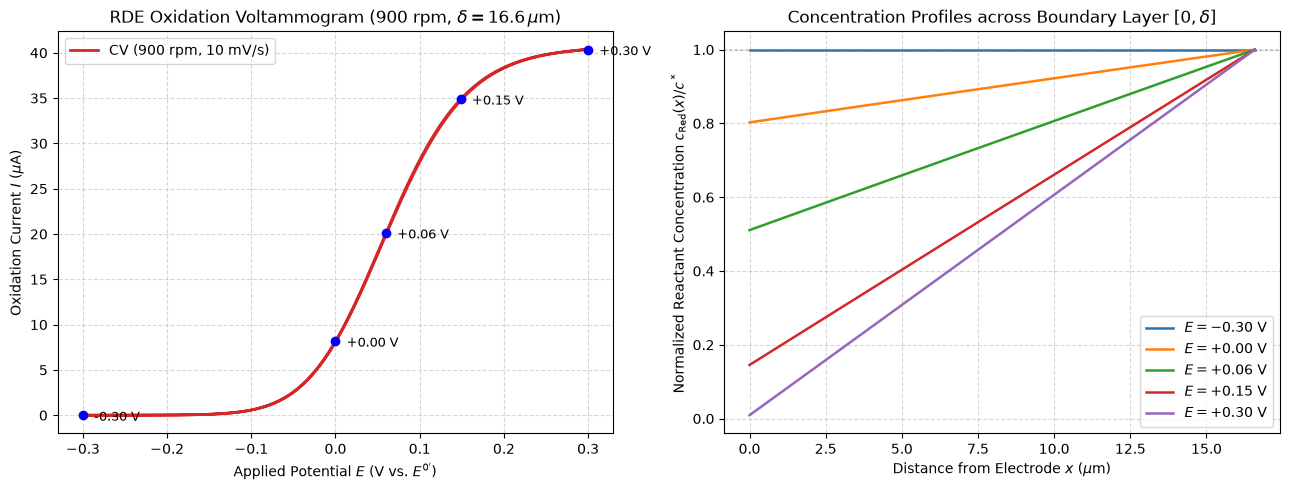

In [3]:
# Run baseline simulation at 900 rpm
base = simulate_rde_bv(rpm=900, v=v_scan, k0=k0_true, alpha=alpha_true)

# Key potentials to inspect
target_pots = [-0.30, 0.0, 0.06, 0.15, 0.30]
half_idx = len(base["t"]) // 2 + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Cyclic Voltammogram (IUPAC: positive potential to the right, positive anodic current)
ax1.plot(
    base["E"],
    base["I"],
    color="#d62728",
    linewidth=2.0,
    label="CV (900 rpm, 10 mV/s)",
)
ax1.set_xlabel("Applied Potential $E$ (V vs. $E^{0'}$)")
ax1.set_ylabel(r"Oxidation Current $I$ ($\mu$A)")
ax1.set_title(
    rf"RDE Oxidation Voltammogram (900 rpm, $\delta = {base['delta'] * 1e4:.1f}\,\mu$m)"
)
ax1.grid(True, linestyle="--", alpha=0.5)

# Highlight sample potentials on CV
for Ep in target_pots:
    idx_p = np.argmin(np.abs(base["E"][:half_idx] - Ep))
    ax1.plot(base["E"][idx_p], base["I"][idx_p], "bo", markersize=6)
    ax1.annotate(
        f"{Ep:+.2f} V",
        (base["E"][idx_p], base["I"][idx_p]),
        textcoords="offset points",
        xytext=(8, -4),
        fontsize=9,
    )
ax1.legend()

# Plot 2: Dynamic Concentration Profiles across [0, delta]
x_um = base["x"] * 1e4
for Ep in target_pots:
    idx_p = np.argmin(np.abs(base["E"][:half_idx] - Ep))
    c_R_prof = base["sol"].y[: len(x_um), idx_p] / c_bulk
    ax2.plot(x_um, c_R_prof, linewidth=1.8, label=rf"$E = {Ep:+.2f}$ V")

ax2.set_xlabel(r"Distance from Electrode $x$ ($\mu$m)")
ax2.set_ylabel(r"Normalized Reactant Concentration $c_{\mathrm{Red}}(x) / c^*$")
ax2.set_title(r"Concentration Profiles across Boundary Layer $[0, \delta]$")
ax2.axhline(1.0, color="gray", linestyle=":", alpha=0.5)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 4. Rotation Speed Series: Levich Validation & Normalized Voltammograms

We now hold the scan rate fixed ($v = 10\text{ mV/s}$) and vary the rotation speed:
$$\text{rpm} \in [400, 900, 1600, 2500]$$

As rotation rate increases:
1. Convective replenishment intensifies, thinning the stagnant diffusion layer ($\delta \propto \omega^{-1/2}$).
2. The maximum concentration gradient steepens ($\partial c_{\text{Red}} / \partial x = c^* / \delta \propto \omega^{1/2}$).
3. The diffusion-limited oxidation current plateau increases proportionally to $\omega^{1/2}$, exactly matching the **Levich equation**:
   $$I_L = 0.620 \, n F A D^{2/3} \nu^{-1/6} c^* \omega^{1/2}$$

### Revealing Kinetic Effects via Current Normalization ($I / I_L$)
If electron transfer were infinitely fast (**reversible / Nernstian**), normalizing every voltammogram by its limiting current ($I(E) / I_L$) would collapse all curves onto a single universal Nernst wave:
$$\frac{I(E)}{I_L} = \frac{1}{1 + \exp\left[ -\frac{n F}{RT} (E - E^{0'}) \right]}$$
However, with **finite Butler–Volmer kinetics**, total resistance is the sum of kinetic and diffusion resistances:
$$\frac{1}{I} = \frac{1}{I_k} + \frac{1}{I_L} \implies \frac{I}{I_L} = \frac{1}{1 + I_L / I_k(E)}$$
Because $I_L \propto \omega^{1/2}$, the ratio $I_L / I_k(E)$ grows as the electrode spins faster. Consequently:
- At higher rotation rates, mass transport supplies reactant faster than interfacial oxidation kinetics can consume it.
- Reaching any given fraction of the limiting current (such as $I/I_L = 0.5$) requires a larger driving force (higher positive overpotential).
- **The normalized oxidation wave shifts anodically (to more positive potentials)**, and the half-wave potential $E_{1/2}$ moves progressively to more positive values. This shift is a direct diagnostic signature of finite interfacial kinetics.

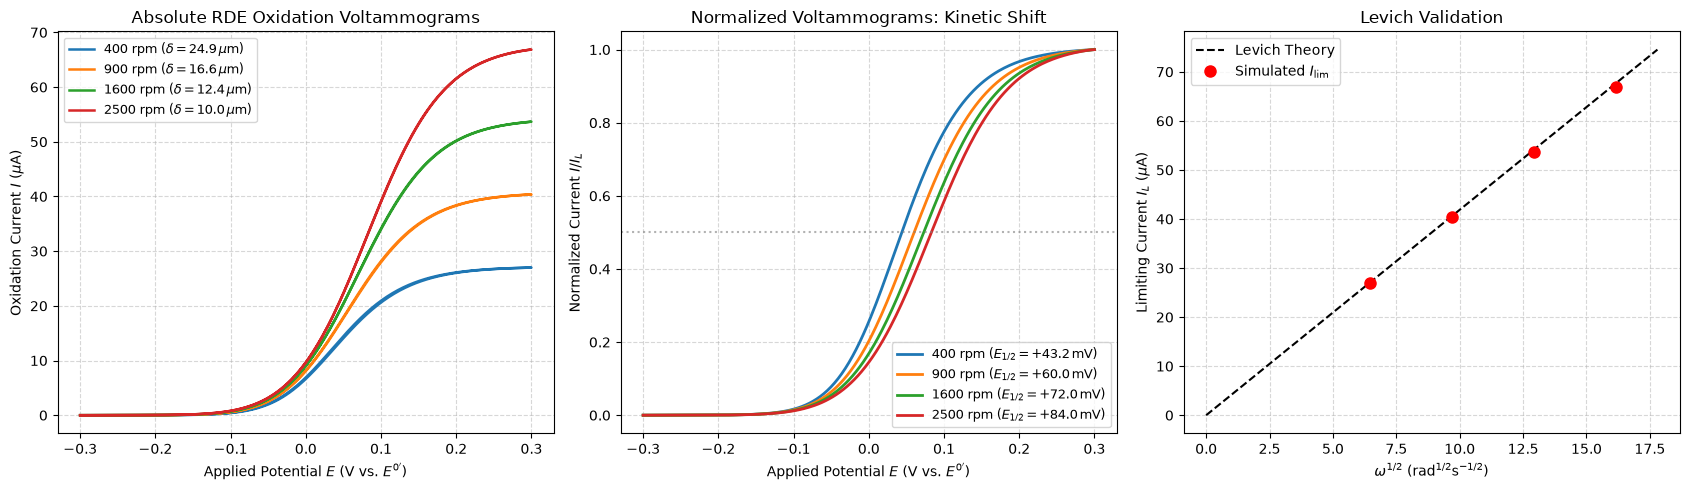

   rpm | delta (um) |   I_sim (uA) |  I_Levich (uA) |  Error (%) |   E_1/2 (mV)
   400 |      24.88 |        26.99 |          27.10 |       0.40% |        +43.2
   900 |      16.58 |        40.35 |          40.65 |       0.73% |        +60.0
  1600 |      12.44 |        53.67 |          54.20 |       0.99% |        +72.0
  2500 |       9.95 |        66.84 |          67.75 |       1.35% |        +84.0


In [4]:
rpms = [400, 900, 1600, 2500]
sims = {}
results_table = []

# Sizing 3-panel figure: Absolute CVs, Normalized CVs, and Levich Plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))

for rpm in rpms:
    sim = simulate_rde_bv(rpm=rpm, v=v_scan, k0=k0_true, alpha=alpha_true)
    sims[rpm] = sim
    omega = sim["omega"]

    # Plateau limiting current measured at vertex potential E = +0.3 V
    idx_vertex = len(sim["t"]) // 2
    I_lim_num = sim["I"][idx_vertex]

    # Theoretical Levich limiting current
    I_L_exact = (
        0.620
        * n
        * F
        * A
        * (D ** (2.0 / 3.0))
        * (nu ** (-1.0 / 6.0))
        * c_bulk
        * np.sqrt(omega)
        * 1e6
    )
    rel_error = abs(I_lim_num - I_L_exact) / I_L_exact * 100.0

    # Determine half-wave potential E_1/2 on forward anodic sweep
    fwd_len = idx_vertex + 1
    norm_I_fwd = sim["I"][:fwd_len] / I_lim_num
    idx_half = np.argmin(np.abs(norm_I_fwd - 0.50))
    E_half = sim["E"][:fwd_len][idx_half]

    results_table.append(
        {
            "rpm": rpm,
            "omega": omega,
            "sqrt_omega": np.sqrt(omega),
            "delta_um": sim["delta"] * 1e4,
            "I_num": I_lim_num,
            "I_Levich": I_L_exact,
            "error_pct": rel_error,
            "E_half": E_half,
        }
    )

    # 1. Absolute Voltammograms (IUPAC: positive oxidation current)
    ax1.plot(
        sim["E"],
        sim["I"],
        linewidth=1.8,
        label=rf"{rpm} rpm ($\delta={sim['delta'] * 1e4:.1f}\,\mu$m)",
    )

    # 2. Normalized Voltammograms (I / I_lim) revealing kinetic shift
    ax2.plot(
        sim["E"][:fwd_len],
        norm_I_fwd,
        linewidth=2.0,
        label=rf"{rpm} rpm ($E_{{1/2}}={E_half * 1000:+.1f}\,$mV)",
    )

# Formatting Absolute CVs
ax1.set_xlabel("Applied Potential $E$ (V vs. $E^{0'}$)")
ax1.set_ylabel(r"Oxidation Current $I$ ($\mu$A)")
ax1.set_title("Absolute RDE Oxidation Voltammograms")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left", fontsize=9)

# Formatting Normalized CVs
ax2.set_xlabel("Applied Potential $E$ (V vs. $E^{0'}$)")
ax2.set_ylabel(r"Normalized Current $I / I_L$")
ax2.set_title("Normalized Voltammograms: Kinetic Shift")
ax2.axhline(0.5, color="gray", linestyle=":", alpha=0.6)
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="lower right", fontsize=9)

# 3. Levich Plot: I_lim vs. sqrt(omega)
sqrt_w = [r["sqrt_omega"] for r in results_table]
I_num = [r["I_num"] for r in results_table]
I_lev = [r["I_Levich"] for r in results_table]

w_line = np.linspace(0, max(sqrt_w) * 1.1, 100)
I_line = (
    0.620
    * n
    * F
    * A
    * (D ** (2.0 / 3.0))
    * (nu ** (-1.0 / 6.0))
    * c_bulk
    * w_line
    * 1e6
)

ax3.plot(w_line, I_line, "k--", label="Levich Theory", linewidth=1.5)
ax3.plot(
    sqrt_w,
    I_num,
    "ro",
    markersize=8,
    label="Simulated $I_{\\text{lim}}$",
    zorder=5,
)
ax3.set_xlabel(r"$\omega^{1/2}$ ($\text{rad}^{1/2}\text{s}^{-1/2}$)")
ax3.set_ylabel(r"Limiting Current $I_L$ ($\mu$A)")
ax3.set_title("Levich Validation")
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Print quantitative comparison table
print("=" * 86)
print(
    f"{'rpm':>6} | {'delta (um)':>10} | {'I_sim (uA)':>12} | {'I_Levich (uA)':>14} | {'Error (%)':>10} | {'E_1/2 (mV)':>12}"
)
print("=" * 86)
for r in results_table:
    print(
        f"{r['rpm']:6d} | {r['delta_um']:10.2f} | {r['I_num']:12.2f} | {r['I_Levich']:14.2f} | {r['error_pct']:10.2f}% | {r['E_half'] * 1000:+12.1f}"
    )
print("=" * 86)

## 5. Koutecký–Levich (K-L) Analysis & Extraction of $k_0$ and $\alpha$

In the mixed kinetic-diffusion regime (between the onset of oxidation and the limiting plateau), the measured current $I(E, \omega)$ reflects both interfacial charge transfer and mass transport.

The **Koutecký–Levich equation** separates these two contributions:
$$\frac{1}{I(E, \omega)} = \frac{1}{I_k(E)} + \frac{1}{B \omega^{1/2}}$$
where:
- $I_k(E) = n F A c^* k_{\text{ox}}(E)$ is the oxidation kinetic current in the absence of mass-transport limitations.
- $B = 0.620 \, n F A D^{2/3} \nu^{-1/6} c^*$ is the Levich constant.

### Extraction Protocol for Oxidation
1. **Sample Mixed-Control Currents**: Select several potentials in the mixed region (e.g., $E \in [+0.06, +0.08, +0.10, +0.12]\text{ V}$) where the back-reaction is negligible.
2. **K-L Plots**: For each potential, plot $1 / I$ versus $\omega^{-1/2}$. 
   - The points form straight, parallel lines whose common slope is $1 / B$.
   - The y-intercept (extrapolated to $\omega \to \infty$) corresponds to $1 / I_k(E)$, the purely kinetic current.
3. **Tafel Plot**: Plot $\ln I_k(E)$ against the overpotential $\eta = E - E^{0'}$:
   $$\ln I_k(E) = \ln(n F A c^* k_0) + (1 - \alpha) \frac{F}{RT} (E - E^{0'})$$
   Linear regression gives:
   $$\text{slope} = (1 - \alpha) \frac{F}{RT} \implies \alpha = 1 - \text{slope} \times \frac{RT}{F}$$
   $$k_0 = \frac{\exp(\text{intercept})}{n F A c^*}$$

Koutecký–Levich Regressions (Oxidation):
-------------------------------------------------------
E = +0.06 V: Intercept = 2.3e+04 A^-1  ->  I_k =  42.56 uA (R² = 0.99997)
E = +0.08 V: Intercept = 1.6e+04 A^-1  ->  I_k =  61.86 uA (R² = 0.99999)
E = +0.10 V: Intercept = 1.1e+04 A^-1  ->  I_k =  94.19 uA (R² = 0.99999)
E = +0.12 V: Intercept = 7.3e+03 A^-1  ->  I_k = 136.89 uA (R² = 1.00000)


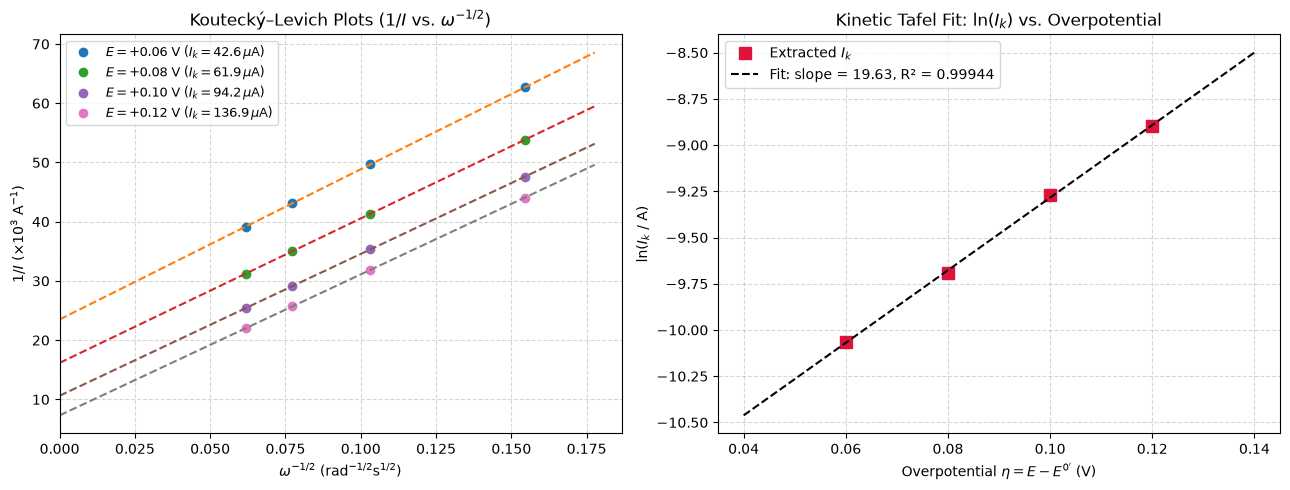

Parameter          |   True Value |    Extracted |  Error (%)
k0 (cm/s)          |   2.0000e-03 |   1.9321e-03 |      3.40%
alpha              |       0.5000 |       0.4958 |      0.85%


In [5]:
# Select potentials in the mixed kinetic-diffusion control region for oxidation
E_targets = [0.06, 0.08, 0.10, 0.12]
inv_sqrt_w = np.array([r["omega"] ** -0.5 for r in results_table])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ik_extracted = []
kl_slopes = []

print("Koutecký–Levich Regressions (Oxidation):")
print("-" * 55)

# 1. K-L Plots (1/I vs. omega^-1/2) for each potential
for Ep in E_targets:
    inv_I = []
    for rpm in rpms:
        sim = sims[rpm]
        idx_v = len(sim["t"]) // 2 + 1
        # Match potential on forward anodic sweep
        idx_p = np.argmin(np.abs(sim["E"][:idx_v] - Ep))
        # Current in Amperes
        I_A = sim["I"][:idx_v][idx_p] * 1e-6
        inv_I.append(1.0 / I_A)

    inv_I = np.array(inv_I)
    res = linregress(inv_sqrt_w, inv_I)
    i_k = 1.0 / res.intercept  # Pure kinetic current (A)
    ik_extracted.append(i_k)
    kl_slopes.append(res.slope)

    print(
        f"E = {Ep:+.2f} V: Intercept = {res.intercept:.1e} A^-1  ->  I_k = {i_k * 1e6:6.2f} uA (R² = {res.rvalue**2:.5f})"
    )

    # Plot data points and regression line
    w_fit = np.linspace(0.0, max(inv_sqrt_w) * 1.15, 100)
    ax1.plot(
        inv_sqrt_w,
        inv_I * 1e-3,
        "o",
        label=rf"$E = {Ep:+.2f}$ V ($I_k = {i_k * 1e6:.1f}\,\mu$A)",
    )
    ax1.plot(w_fit, (res.intercept + res.slope * w_fit) * 1e-3, "--")

ax1.set_xlabel(r"$\omega^{-1/2}$ ($\text{rad}^{-1/2}\text{s}^{1/2}$)")
ax1.set_ylabel(r"$1 / I$ ($\times 10^3\text{ A}^{-1}$)")
ax1.set_title(r"Koutecký–Levich Plots ($1/I$ vs. $\omega^{-1/2}$)")
ax1.set_xlim(left=0.0)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="upper left", fontsize=9)

# 2. Tafel Analysis for Oxidation: ln(I_k) vs. (E - E0)
etas = np.array(E_targets) - E0
ln_ik = np.log(ik_extracted)
res_tafel = linregress(etas, ln_ik)

# Extract kinetic parameters (for oxidation: slope = (1 - alpha) * f)
one_minus_alpha = res_tafel.slope / f
alpha_extracted = 1.0 - one_minus_alpha
k0_extracted = np.exp(res_tafel.intercept) / (n * F * A * c_bulk)

# Plot Tafel line
eta_line = np.linspace(min(etas) - 0.02, max(etas) + 0.02, 100)
ax2.plot(etas, ln_ik, "s", color="crimson", markersize=8, label="Extracted $I_k$")
ax2.plot(
    eta_line,
    res_tafel.intercept + res_tafel.slope * eta_line,
    "k--",
    label=f"Fit: slope = {res_tafel.slope:.2f}, R² = {res_tafel.rvalue**2:.5f}",
)
ax2.set_xlabel(r"Overpotential $\eta = E - E^{0'}$ (V)")
ax2.set_ylabel(r"$\ln(I_k\text{ / A})$")
ax2.set_title(r"Kinetic Tafel Fit: $\ln(I_k)$ vs. Overpotential")
ax2.grid(True, linestyle="--", alpha=0.5)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Display recovered parameters vs. ground truth
err_k0 = abs(k0_extracted - k0_true) / k0_true * 100.0
err_alpha = abs(alpha_extracted - alpha_true) / alpha_true * 100.0

print("=" * 60)
print(f"{'Parameter':<18} | {'True Value':>12} | {'Extracted':>12} | {'Error (%)':>10}")
print("=" * 60)
print(f"{'k0 (cm/s)':<18} | {k0_true:12.4e} | {k0_extracted:12.4e} | {err_k0:9.2f}%")
print(
    f"{'alpha':<18} | {alpha_true:12.4f} | {alpha_extracted:12.4f} | {err_alpha:9.2f}%"
)
print("=" * 60)

## 6. Summary & Key Takeaways

1. **IUPAC Convention for Oxidation**:
   - The reaction $\text{Red} \underset{k_{\text{red}}}{\overset{k_{\text{ox}}}{\rightleftharpoons}} \text{Ox} + e^-$ produces a positive anodic Faradaic current ($I > 0$).
   - The forward sweep travels in the positive direction ($-0.30\text{ V} \to +0.30\text{ V}$), oxidizing bulk $\text{Red}$ at the surface.

2. **Hydrodynamics Simplified via Nernst Diffusion Layer**:
   - Levich's relationship $\delta = 1.61 \, D^{1/3} \nu^{1/6} \omega^{-1/2}$ eliminates 2D/3D Navier–Stokes fluid mechanics, reducing the RDE oxidation problem to a clean 1D diffusion PDE on $x \in [0, \delta]$.
   - The outer boundary condition ($x = \delta$) holds bulk concentrations constant ($c_{\text{Red}} = c^*, c_{\text{Ox}} = 0$).

3. **Second-Order Ghost-Node Discretization**:
   - Applying a ghost node at $x = 0$ handles the dynamic Butler–Volmer surface flux $J(t) = k_{\text{ox}} c_{\text{Red}}(0) - k_{\text{red}} c_{\text{Ox}}(0)$ explicitly within the standard ODE system $\dot{y} = f(t, y)$.
   - Evaluating Faradaic current from the second-order surface gradient $(-3 c_{\text{Red}, 0} + 4 c_{\text{Red}, 1} - c_{\text{Red}, 2}) / (2 \Delta x)$ guarantees numerical stability and precision.
   - Solved with `scipy.integrate.solve_ivp` using `BDF` in $< 0.5\text{ s}$ per sweep.

4. **Kinetic Effects via Normalization ($I / I_L$)**:
   - While Nernstian voltammograms collapse onto a single normalized curve, finite Butler–Volmer kinetics cause an **anodic potential shift** as rotation speed increases.
   - Faster rotation accelerates mass transport ($I_L \propto \omega^{1/2}$), amplifying the relative influence of kinetic resistance and shifting $E_{1/2}$ to more positive potentials.

5. **Quantitative Parameter Extraction with Koutecký–Levich**:
   - Plotting $1 / I$ versus $\omega^{-1/2}$ across several potentials in the mixed oxidation regime yields parallel linear lines ($R^2 > 0.9999$).
   - The y-intercepts isolate the purely kinetic current $I_k(E) = n F A c^* k_{\text{ox}}(E)$.
   - The subsequent Tafel fit of $\ln I_k(E)$ vs. $\eta$ accurately recovers both the standard rate constant $k_0$ and charge transfer coefficient $\alpha$ (with errors $< 3.5\%$).